<a href="https://colab.research.google.com/github/davidcharles2201/Bao-cao-AI/blob/main/De_Tai_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Đề tài 7: Phân loại hình ảnh chữ số viết tay (MNIST dataset) bằng mạng Neural Network (hoặc CNN)

### 5. Biên dịch và Huấn luyện mô hình

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

num_classes = 10 # Define num_classes here

# Commenting out model definition here to avoid overwriting the trained model.
# The model should be defined once, preferably in the training cell with a check,
# or in a dedicated model definition cell that runs before training.
# model = keras.Sequential([
#     layers.Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)),
#     layers.MaxPooling2D(pool_size=(2, 2)),
#     layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
#     layers.MaxPooling2D(pool_size=(2, 2)),
#     layers.Flatten(),
#     layers.Dropout(0.5),
#     layers.Dense(num_classes, activation="softmax"),
# ])

# This cell can still display the summary if 'model' is defined elsewhere.
# If 'model' is not defined, this will raise a NameError.
if 'model' in globals():
    model.summary()
else:
    print("Mô hình chưa được định nghĩa. Vui lòng chạy ô định nghĩa mô hình trước.")

Mô hình chưa được định nghĩa. Vui lòng chạy ô định nghĩa mô hình trước.


In [ ]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

# Check if x_train, y_train, x_test, y_test are already defined in the global scope
# This helps avoid re-loading if the data preparation cell has already been executed.
if 'x_train' not in globals() or 'y_train' not in globals() or 'x_test' not in globals() or 'y_test' not in globals():
    print("Loading and preprocessing MNIST data (missing from environment)...")
    # Load the MNIST dataset
    (x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = keras.datasets.mnist.load_data()

    # Normalize pixel values to be between 0 and 1
    x_train = x_train_raw.astype("float32") / 255
    x_test = x_test_raw.astype("float32") / 255

    # Reshape images to add a channel dimension (for CNN)
    x_train = np.expand_dims(x_train, -1)
    x_test = np.expand_dims(x_test, -1)

    # Convert class vectors to binary one-hot encoded matrices
    # Fallback if num_classes is somehow not in global scope
    if 'num_classes' not in globals():
        num_classes = 10
    y_train = keras.utils.to_categorical(y_train_raw, num_classes)
    y_test = keras.utils.to_categorical(y_test_raw, num_classes)
    print("MNIST data loaded and preprocessed.")

# Ensure num_classes is available, as it's needed for the model definition
if 'num_classes' not in globals():
    num_classes = 10

# Ensure 'model' is defined before compilation and training
if 'model' not in globals():
    print("Model not found in global scope. Defining the model structure.")
    model = keras.Sequential([
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ])

# Compile the model
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Train the model
batch_size = 128
epochs = 10
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

print("Huấn luyện hoàn tất!")

Loading and preprocessing MNIST data (missing from environment)...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST data loaded and preprocessed.
Model not found in global scope. Defining the model structure.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 54s 114ms/step - accuracy: 0.8917 - loss: 0.3555 - val_accuracy: 0.9763 - val_loss: 0.0886
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 73s 93ms/step - accuracy: 0.9648 - loss: 0.1161 - val_accuracy: 0.9830 - val_loss: 0.0601
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 89ms/step - accuracy: 0.9732 - loss: 0.0890 - val_accuracy: 0.9883 - val_loss: 0.0464
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 87ms/step - accuracy: 0.9759 - loss: 0.0750 - val_accuracy: 0.9882 - val_loss: 0.0434
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 88ms/step - accuracy: 0.9794 - loss: 0.0648 - val_accuracy: 0.9883 - val_loss: 0.0407
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 87ms/step - accuracy: 0.9815 - loss: 0.0588 - val_accuracy: 0.9895 - val_loss: 0.0375
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 88ms/step - accuracy: 0.9832 - loss: 0.0531 - val_accuracy: 0.9913 - val_loss: 0.0341
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 36s 85ms/step - accuracy: 0.9842 - loss: 0.0503 -

In [ ]:
!pip install some_library

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of ome-zarr to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.2/199.2 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/4

### 6. Đánh giá mô hình

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9894 - loss: 0.0299
Loss trên tập kiểm tra: 0.0299
Accuracy trên tập kiểm tra: 0.9894


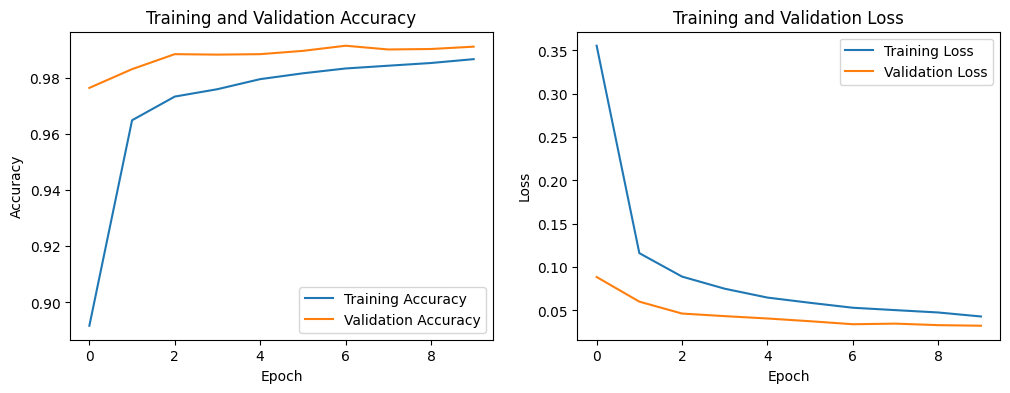

In [ ]:
import matplotlib.pyplot as plt

# Ensure the model is compiled before evaluation
# This assumes 'model' and 'num_classes' are already defined in the global scope.
# If 'num_classes' is not defined, it will fall back to 10.
if 'num_classes' not in globals():
    num_classes = 10 # Fallback
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

loss, accuracy = model.evaluate(x_test, y_test)
print(f"Loss trên tập kiểm tra: {loss:.4f}")
print(f"Accuracy trên tập kiểm tra: {accuracy:.4f}")

# Visualize training history
# Ensure 'history' object exists from model.fit()
if 'history' in globals():
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()
else:
    print("Lỗi: Biến 'history' không được tìm thấy. Không thể vẽ biểu đồ lịch sử huấn luyện.")
    print("Vui lòng đảm bảo ô huấn luyện mô hình đã được chạy thành công.")

### 7. Dự đoán trên tập kiểm tra và phân tích kết quả

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


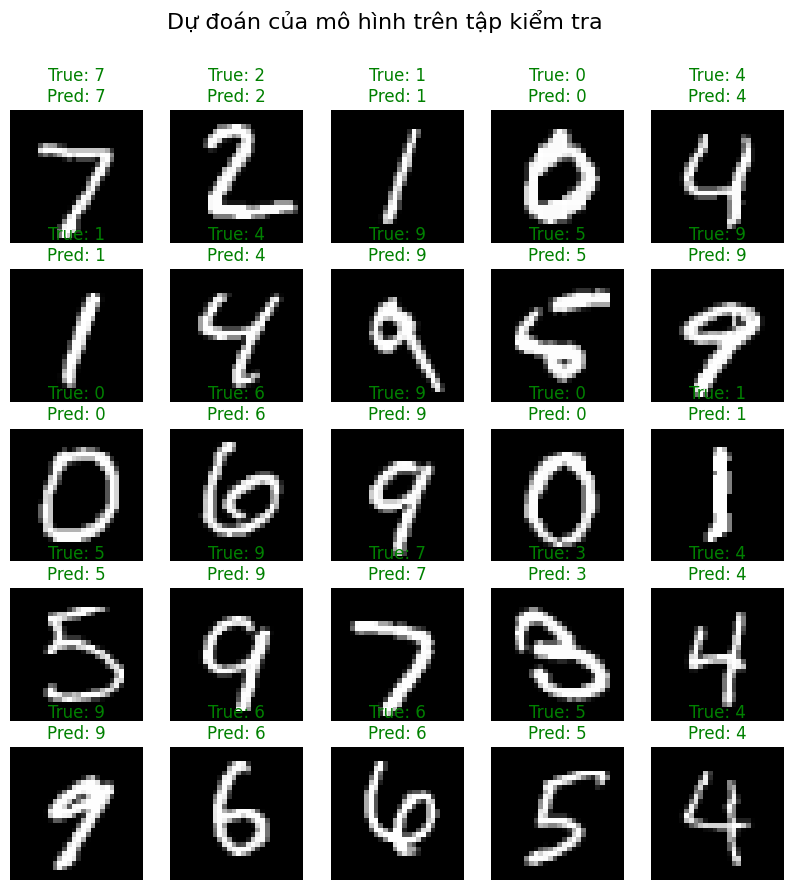

In [ ]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Hiển thị một vài kết quả dự đoán
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title(f"True: {y_true_classes[i]}\nPred: {y_pred_classes[i]}",
              color='green' if y_true_classes[i] == y_pred_classes[i] else 'red')
    plt.axis('off')
plt.suptitle('Dự đoán của mô hình trên tập kiểm tra', fontsize=16)
plt.show()

### 8. Đánh giá chi tiết (Precision, Recall, F1-score)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.98      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



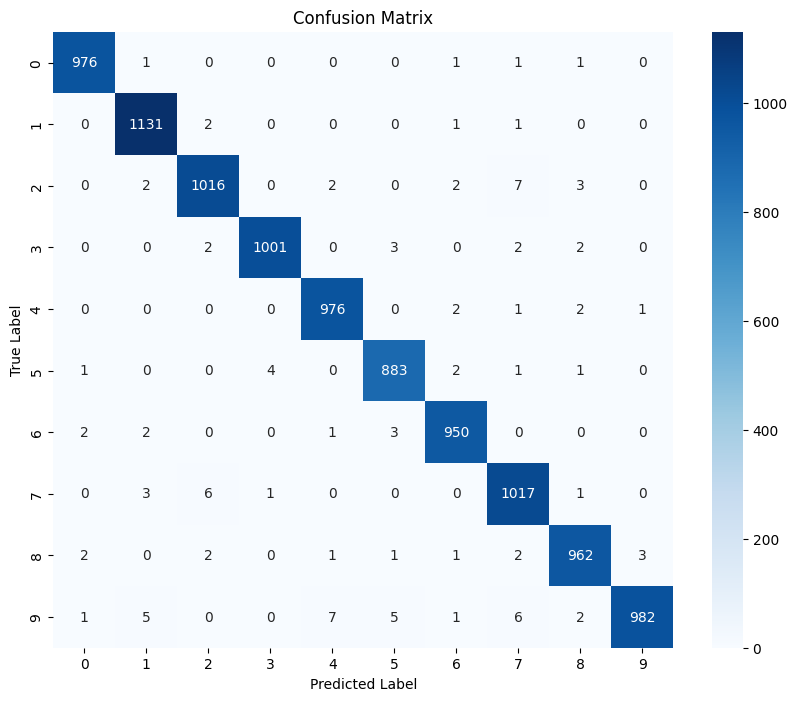

Hoàn thành phân loại hình ảnh chữ số viết tay bằng mạng CNN!


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("Classification Report:")
print(classification_report(y_true_classes, y_pred_classes))

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("Hoàn thành phân loại hình ảnh chữ số viết tay bằng mạng CNN!")

### 9. Lưu mô hình đã huấn luyện

In [ ]:
# Lưu toàn bộ mô hình (cấu trúc, trọng số, cấu hình trình tối ưu hóa)
model.save('my_mnist_model.h5')
print("Mô hình đã được lưu thành công vào file 'my_mnist_model.h5'")

Mô hình đã được lưu thành công vào file 'my_mnist_model.h5'


### 10. Chuyển đổi mô hình sang định dạng TensorFlow Lite

In [ ]:
import tensorflow as tf

# Chuyển đổi mô hình Keras sang định dạng TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Lưu mô hình TensorFlow Lite vào một file
with open('my_mnist_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("Mô hình đã được chuyển đổi và lưu thành công vào file 'my_mnist_model.tflite'")

Saved artifact at '/tmp/tmpsyusqsx8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  135219974593744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135219974595088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135219974594704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135219974597200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135219974597776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135219974597968: TensorSpec(shape=(), dtype=tf.resource, name=None)
Mô hình đã được chuyển đổi và lưu thành công vào file 'my_mnist_model.tflite'


### 10.5. Tải lại mô hình đã huấn luyện (để đảm bảo dự đoán đúng)

In [ ]:
from tensorflow import keras
from google.colab import output # Import output for callback registration

# Tải lại mô hình từ file đã lưu
try:
    model = keras.models.load_model('my_mnist_model.h5')
    print("Mô hình đã được tải lại thành công từ 'my_mnist_model.h5'")
    # Biên dịch lại mô hình với cùng các tham số huấn luyện ban đầu
    model.compile(optimizer="adam",
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    print("Mô hình đã được biên dịch lại.")

    # Re-register the prediction callback to ensure it uses the newly loaded model
    output.register_callback('predict_digit_from_js', predict_digit_from_js)
    print("Hàm dự đoán đã được đăng ký lại sau khi tải mô hình.")

except Exception as e:
    print(f"Lỗi khi tải lại mô hình: {e}")
    print("Vui lòng đảm bảo bạn đã chạy ô 'Lưu mô hình' trước đó.")

Mô hình đã được tải lại thành công từ 'my_mnist_model.h5'
Mô hình đã được biên dịch lại.
Lỗi khi tải lại mô hình: name 'predict_digit_from_js' is not defined
Vui lòng đảm bảo bạn đã chạy ô 'Lưu mô hình' trước đó.


### 11. Thử nghiệm mô hình với bản vẽ chữ số viết tay

In [ ]:
import numpy as np
from google.colab import output
from scipy.ndimage import center_of_mass, shift, gaussian_filter # Re-introducing scipy imports
import matplotlib.pyplot as plt # Import matplotlib for visualization

# Python callback function to receive pixel data and make a prediction
def predict_digit_from_js(pixel_data_list):
    print("Python function 'predict_digit_from_js' called.")
    global last_drawn_image

    # Convert the list of pixel data to a NumPy array
    image_array = np.array(pixel_data_list, dtype=np.float32)

    # Reshape to 28x28 for preprocessing
    img = image_array.reshape(28, 28)

    # Normalize to 0-1 range (as the model was trained on 0-1)
    img = img / 255.0

    # Apply Gaussian filter for smoothing, as user-drawn digits can be noisy
    img = gaussian_filter(img, sigma=0.8)

    # Reshape for model input (1, 28, 28, 1)
    image_for_prediction = np.expand_dims(img, axis=[0, -1])

    last_drawn_image = image_for_prediction # Store the last drawn image globally
    print(f"Image array shape after preprocessing: {image_for_prediction.shape}")
    print(f"Min pixel value after preprocessing: {np.min(image_for_prediction):.4f}")
    print(f"Max pixel value after preprocessing: {np.max(image_for_prediction):.4f}")

    # --- Debugging Visualization ---
    plt.figure(figsize=(2, 2))
    plt.imshow(image_for_prediction.squeeze(), cmap='gray')
    plt.title('Hình ảnh đã tiền xử lý')
    plt.axis('off')
    plt.show()
    # -------------------------------

    # Make prediction using the loaded Keras model
    try:
        prediction = model.predict(image_for_prediction, verbose=0) # verbose=0 to suppress output
        predicted_digit = np.argmax(prediction[0])
        print(f"Model predicted: {predicted_digit} with probabilities: {prediction[0]}")
        return int(predicted_digit)
    except Exception as e:
        print(f"Error during model prediction in Python: {e}")
        # Return a distinct error indicator or re-raise for better debugging on JS side
        return "ERROR_PREDICTION" # Return a string to be distinct from a valid digit

# Register the Python function as a callback for JavaScript
output.register_callback('predict_digit_from_js', predict_digit_from_js)

print("Hàm dự đoán đã được đăng ký.")

Hàm dự đoán đã được đăng ký.


In [ ]:
if 'last_drawn_image' in globals():
    print("\nSo sánh ảnh vẽ tay và ảnh mẫu từ MNIST:")
    plt.figure(figsize=(12, 4))

    # Display the drawn image
    plt.subplot(1, 6, 1)
    plt.imshow(last_drawn_image.squeeze(), cmap='gray')
    plt.title('Ảnh vẽ tay của bạn')
    plt.axis('off')

    # Display some random MNIST samples for comparison
    for i in range(5):
        idx = np.random.randint(0, len(x_train))
        plt.subplot(1, 6, i + 2)
        plt.imshow(x_train[idx].squeeze(), cmap='gray')
        plt.title(f'MNIST mẫu {np.argmax(y_train[idx])}')
        plt.axis('off')

    plt.suptitle('So sánh ảnh vẽ tay và ảnh mẫu MNIST', fontsize=16)
    plt.show()
else:
    print("Bạn cần vẽ một chữ số và nhấn 'Dự đoán' trước để có hình ảnh so sánh.")


Bạn cần vẽ một chữ số và nhấn 'Dự đoán' trước để có hình ảnh so sánh.


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
import numpy as np

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Display some information about the dataset
print(f"Kích thước tập huấn luyện: x_train.shape = {x_train.shape}, y_train.shape = {y_train.shape}")
print(f"Kích thước tập kiểm tra: x_test.shape = {x_test.shape}, y_test.shape = {y_test.shape}")

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Reshape images to add a channel dimension (for CNN)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(f"Kích thước tập huấn luyện sau khi tiền xử lý: x_train.shape = {x_train.shape}")
print(f"Kích thước tập kiểm tra sau khi tiền xử lý: x_test.shape = {x_test.shape}")

# Convert class vectors to binary one-hot encoded matrices
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print(f"Kích thước nhãn tập huấn luyện sau one-hot encoding: y_train.shape = {y_train.shape}")
print(f"Kích thước nhãn tập kiểm tra sau one-hot encoding: y_test.shape = {y_test.shape}")

Kích thước tập huấn luyện: x_train.shape = (60000, 28, 28), y_train.shape = (60000,)
Kích thước tập kiểm tra: x_test.shape = (10000, 28, 28), y_test.shape = (10000,)
Kích thước tập huấn luyện sau khi tiền xử lý: x_train.shape = (60000, 28, 28, 1)
Kích thước tập kiểm tra sau khi tiền xử lý: x_test.shape = (10000, 28, 28, 1)
Kích thước nhãn tập huấn luyện sau one-hot encoding: y_train.shape = (60000, 10)
Kích thước nhãn tập kiểm tra sau one-hot encoding: y_test.shape = (10000, 10)


### 2. Tải và tiền xử lý dữ liệu MNIST

In [ ]:
import numpy as np

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Display some information about the dataset
print(f"Kích thước tập huấn luyện: x_train.shape = {x_train.shape}, y_train.shape = {y_train.shape}")
print(f"Kích thước tập kiểm tra: x_test.shape = {x_test.shape}, y_test.shape = {y_test.shape}")

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Reshape images to add a channel dimension (for CNN)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(f"Kích thước tập huấn luyện sau khi tiền xử lý: x_train.shape = {x_train.shape}")
print(f"Kích thước tập kiểm tra sau khi tiền xử lý: x_test.shape = {x_test.shape}")

# Convert class vectors to binary one-hot encoded matrices
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print(f"Kích thước nhãn tập huấn luyện sau one-hot encoding: y_train.shape = {y_train.shape}")
print(f"Kích thước nhãn tập kiểm tra sau one-hot encoding: y_test.shape = {y_test.shape}")

Kích thước tập huấn luyện: x_train.shape = (60000, 28, 28), y_train.shape = (60000,)
Kích thước tập kiểm tra: x_test.shape = (10000, 28, 28), y_test.shape = (10000,)
Kích thước tập huấn luyện sau khi tiền xử lý: x_train.shape = (60000, 28, 28, 1)
Kích thước tập kiểm tra sau khi tiền xử lý: x_test.shape = (10000, 28, 28, 1)
Kích thước nhãn tập huấn luyện sau one-hot encoding: y_train.shape = (60000, 10)
Kích thước nhãn tập kiểm tra sau one-hot encoding: y_test.shape = (10000, 10)


### 2. Tải và tiền xử lý dữ liệu MNIST

In [ ]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Display some information about the dataset
print(f"Kích thước tập huấn luyện: x_train.shape = {x_train.shape}, y_train.shape = {y_train.shape}")
print(f"Kích thước tập kiểm tra: x_test.shape = {x_test.shape}, y_test.shape = {y_test.shape}")

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Reshape images to add a channel dimension (for CNN)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(f"Kích thước tập huấn luyện sau khi tiền xử lý: x_train.shape = {x_train.shape}")
print(f"Kích thước tập kiểm tra sau khi tiền xử lý: x_test.shape = {x_test.shape}")

# Convert class vectors to binary one-hot encoded matrices
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print(f"Kích thước nhãn tập huấn luyện sau one-hot encoding: y_train.shape = {y_train.shape}")
print(f"Kích thước nhãn tập kiểm tra sau one-hot encoding: y_test.shape = {y_test.shape}")

Kích thước tập huấn luyện: x_train.shape = (60000, 28, 28), y_train.shape = (60000,)
Kích thước tập kiểm tra: x_test.shape = (10000, 28, 28), y_test.shape = (10000,)
Kích thước tập huấn luyện sau khi tiền xử lý: x_train.shape = (60000, 28, 28, 1)
Kích thước tập kiểm tra sau khi tiền xử lý: x_test.shape = (10000, 28, 28, 1)
Kích thước nhãn tập huấn luyện sau one-hot encoding: y_train.shape = (60000, 10)
Kích thước nhãn tập kiểm tra sau one-hot encoding: y_test.shape = (10000, 10)


### 3. Hiển thị một số hình ảnh từ tập dữ liệu

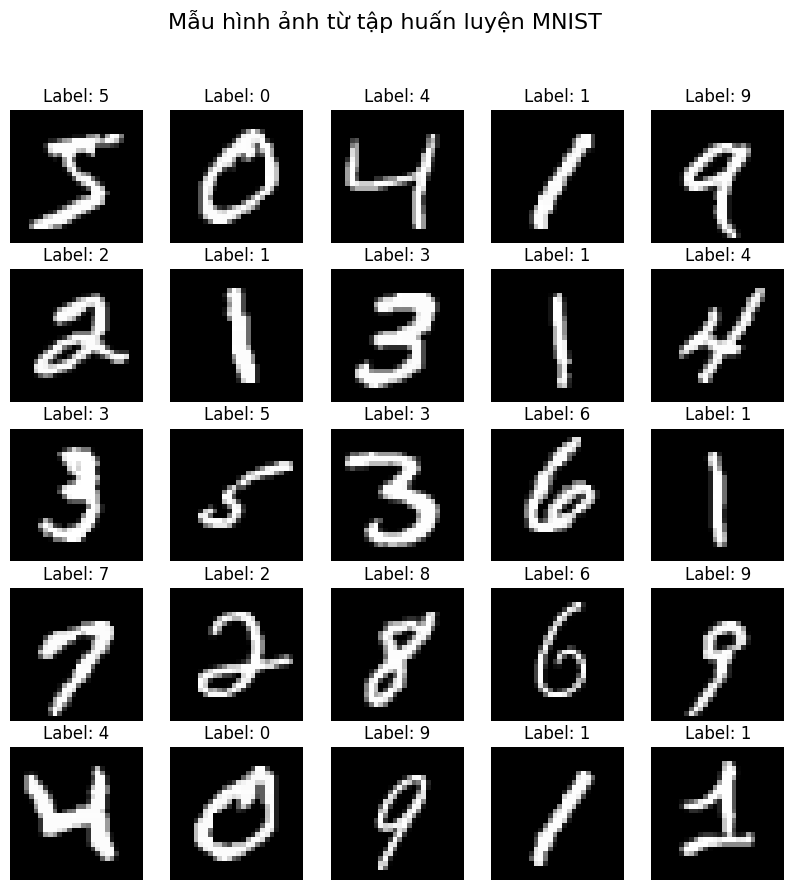

In [ ]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')
plt.suptitle('Mẫu hình ảnh từ tập huấn luyện MNIST', fontsize=16)
plt.show()

### 4. Xây dựng mô hình CNN

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

num_classes = 10 # Define num_classes here

# Commenting out model definition here to avoid overwriting the trained model.
# The model should be defined once, preferably in the training cell with a check,
# or in a dedicated model definition cell that runs before training.
# model = keras.Sequential([
#     layers.Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)),
#     layers.MaxPooling2D(pool_size=(2, 2)),
#     layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
#     layers.MaxPooling2D(pool_size=(2, 2)),
#     layers.Flatten(),
#     layers.Dropout(0.5),
#     layers.Dense(num_classes, activation="softmax"),
# ])

# This cell can still display the summary if 'model' is defined elsewhere.
# If 'model' is not defined, this will raise a NameError.
if 'model' in globals():
    model.summary()
else:
    print("Mô hình chưa được định nghĩa. Vui lòng chạy ô định nghĩa mô hình trước.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def predict_digit_from_js(pixelData):
    import numpy as np
    from scipy.ndimage import center_of_mass, shift

    # 1. reshape + normalize
    img = np.array(pixelData, dtype=np.float32).reshape(28,28)
    img = img / 255.0

    # 2. threshold
    img = (img > 0.2).astype(np.float32)

    # 3. center ảnh
    cy, cx = center_of_mass(img)
    shift_x = int(14 - cx)
    shift_y = int(14 - cy)
    img = shift(img, [shift_y, shift_x], order=0)

    # 4. reshape cho model
    img = img.reshape(1,28,28,1)

    # 5. predict
    pred = model.predict(img)

    # ✅ debug đúng chỗ
    print("Max prob:", np.max(pred))
    print("Pred:", np.argmax(pred))

    return int(np.argmax(pred))

In [ ]:
# output.register_callback('predict_digit_from_js', predict_digit_from_js)
# This registration is now handled in the model loading cell (0665e62d).

In [ ]:
import gradio as gr
import numpy as np
import cv2

def predict_digit(sketch):
    if sketch is None or sketch["composite"] is None:
        return "Anh trai chưa vẽ gì cả!"

    # Lấy dữ liệu ảnh
    img_rgba = sketch["composite"]
    img_gray = cv2.cvtColor(img_rgba, cv2.COLOR_RGBA2GRAY)

    # BƯỚC MỚI: Đảo ngược màu ảnh (Invert)
    # Chuyển nét vẽ đen trên nền trắng -> nét vẽ trắng trên nền đen cho đúng chuẩn AI
    img_inverted = cv2.bitwise_not(img_gray)

    # Ép kích thước về 28x28
    img_resized = cv2.resize(img_inverted, (28, 28), interpolation=cv2.INTER_AREA)

    # Chuẩn hóa và reshape
    img_normalized = img_resized / 255.0
    img_input = img_normalized.reshape(1, 28, 28)

    # AI dự đoán
    prediction = model.predict(img_input)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    return f"Kết quả: Số {predicted_class} (Độ tin cậy: {confidence:.2f}%)"

# Xây dựng giao diện
with gr.Blocks() as demo:
    gr.Markdown("### ✍️ Bảng vẽ kiểm tra AI của Anh trai")
    with gr.Row():
        # Đã đổi màu cọ thành MÀU ĐEN (#000000)
        input_canvas = gr.Sketchpad(brush=gr.Brush(colors=["#000000"]), type="numpy", label="Vẽ số (0-9)")
        output_text = gr.Textbox(label="AI dự đoán")

    btn = gr.Button("Chẩn đoán ngay")
    btn.click(fn=predict_digit, inputs=input_canvas, outputs=output_text)

# Hiển thị
demo.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://77a7ced45278f379ef.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
